# Install packages

# Import

In [1]:
import os
import time
import torch
import numpy as np
from tqdm import tqdm
import torch.nn.functional as F
from torch_geometric.loader import DataLoader
from torch_geometric.datasets import TUDataset
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
device

device(type='cuda')

# Model

In [2]:
import torch.nn.functional as F
from torch_geometric.nn import GCNConv, global_max_pool

class Classify_graph(torch.nn.Module):
    def __init__(self, num_layer, num_feature, num_hidden, num_classes):
        super(Classify_graph, self).__init__()
        self.num_layers = num_layer
        self.conv = torch.nn.ModuleList()
        self.conv.append(GCNConv(num_feature, num_hidden))
        for i in range(self.num_layers - 1):
            self.conv.append(GCNConv(num_hidden, num_hidden))
        self.lt1 = torch.nn.Linear(num_hidden, num_classes)

    def reset_parameters(self):
        for module in self.conv:
            module.reset_parameters()
        self.lt1.reset_parameters()

    def forward(self, gc):
        x, edge_index, batch = gc.x, gc.edge_index, gc.batch
        for i in range(self.num_layers):
            x = self.conv[i](x, edge_index)
            x = F.elu(x)
            x = F.dropout(x, training=self.training)
        x = global_max_pool(x, batch)
        x = self.lt1(x)
        return F.softmax(x, dim=1)

# Utils

In [3]:
def train_test_val_split(dataset, shuffle=True):
    N = len(dataset)
    if shuffle:
        idx = torch.randperm(N)
    else:
        idx = torch.arange(N)
    train = []
    val = []
    test = []
    for i in range(N):
        if i < N//2:
            train.append(dataset[idx[i]])
        elif i < 3*N//4 and i >= N//2:
            val.append(dataset[idx[i]])
        else:
            test.append(dataset[idx[i]])
    return train, test, val

In [4]:
def train_model(train_loader, model, loss_fn, optimizer):
  all_output_train = torch.tensor([])
  all_labels_train = torch.tensor([])
  train_loss = 0
  model.train()
  optimizer.zero_grad()

  for graphs in train_loader:
    out = model(graphs)
    loss = loss_fn(out, graphs.y)
    train_loss += loss.item()
    all_output_train = torch.cat((all_output_train, out))
    all_labels_train = torch.cat((all_labels_train, graphs.y))
    loss.backward()
    optimizer.step()

  train_acc = int(torch.sum(torch.argmax(all_output_train, dim=1) == all_labels_train).item()) / len(all_labels_train)
  train_loss = train_loss / len(train_loader)

  return train_acc, train_loss

def infer_model(loader, model, loss_fn):
  all_output = torch.tensor([])
  all_labels = torch.tensor([])
  all_loss = 0
  model.eval()

  for graphs in loader:
    out = model(graphs)
    loss = loss_fn(out, graphs.y)
    all_loss += loss.item()
    all_output = torch.cat((all_output, out))
    all_labels = torch.cat((all_labels, graphs.y))

  acc = int(torch.sum(torch.argmax(all_output, dim=1) == all_labels).item()) / len(all_labels)
  all_loss = all_loss / len(loader)

  return acc, all_loss

# Main

In [5]:
dataset = TUDataset(root='./dataset', name='ENZYMES')
train_split, test_split, val_split = train_test_val_split(dataset, shuffle=True)
train_loader = DataLoader(train_split, batch_size=128, shuffle=True)
val_loader = DataLoader(val_split, batch_size=128, shuffle=False)
test_loader = DataLoader(test_split, batch_size=128, shuffle=False)

num_layer = 2
num_feature = dataset[0].x.shape[1]
num_hidden = 512
num_classes = dataset.num_classes

model = Classify_graph(num_layer, num_feature, num_hidden, num_classes)
loss_fn = torch.nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001, weight_decay=5e-4)

In [6]:
best_val_loss = float('inf')
best_test_loss = float('inf')
best_val_acc = 0
best_test_acc = 0
all_train_loss = []
all_val_loss = []
all_test_loss = []
for epoch in tqdm(range(100)):
  #Train model
  train_acc, train_loss = train_model(train_loader, model, loss_fn, optimizer)
  all_train_loss.append(train_loss)
  #Validate Model
  val_acc, val_loss = infer_model(val_loader, model, loss_fn)
  all_val_loss.append(val_loss)
  #Test Model
  test_acc, test_loss = infer_model(test_loader, model, loss_fn)
  all_test_loss.append(test_loss)
  #save model
  if val_loss <= best_val_loss or epoch == 0:
    best_val_loss = val_loss
    best_test_loss = test_loss
    best_val_acc = val_acc
    best_test_acc = test_acc
    torch.save(model.state_dict(), 'final_models/baseline_ENZYMES_batch_128_lr_0.001_hidden.pt')
    print("\n")
    print(f"train acc: {train_acc}")
    print(f"val acc: {val_acc}")
    print(f"test acc: {test_acc}")
    print("Best model saved")
    print("\n")

  if epoch == 0 or epoch%25 == 0:
    print("\n")
    print(f"train acc: {train_acc}")
    print(f"val acc: {val_acc}")
    print(f"test acc: {test_acc}")
    print("\n")


print("\n")
print(f"Best Val Loss: {best_val_loss}")
print(f"Best Test Loss: {best_test_loss}")
print(f"Best Val Acc: {best_val_acc}")
print(f"Best Test Acc: {best_test_acc}")

  1%|          | 1/100 [00:13<23:04, 13.99s/it]



train acc: 0.17
val acc: 0.23333333333333334
test acc: 0.14666666666666667
Best model saved




train acc: 0.17
val acc: 0.23333333333333334
test acc: 0.14666666666666667




  2%|▏         | 2/100 [00:28<23:06, 14.15s/it]



train acc: 0.25
val acc: 0.26
test acc: 0.18666666666666668
Best model saved




  3%|▎         | 3/100 [00:42<22:43, 14.05s/it]

...



train acc: 0.39
val acc: 0.25333333333333335
test acc: 0.17333333333333334




 76%|███████▌  | 76/100 [17:19<05:33, 13.91s/it]



train acc: 0.38333333333333336
val acc: 0.28
test acc: 0.18666666666666668




100%|██████████| 100/100 [22:51<00:00, 13.71s/it]



Best Val Loss: 1.7263553738594055
Best Test Loss: 1.8249687552452087
Best Val Acc: 0.28
Best Test Acc: 0.2


# Plot loss

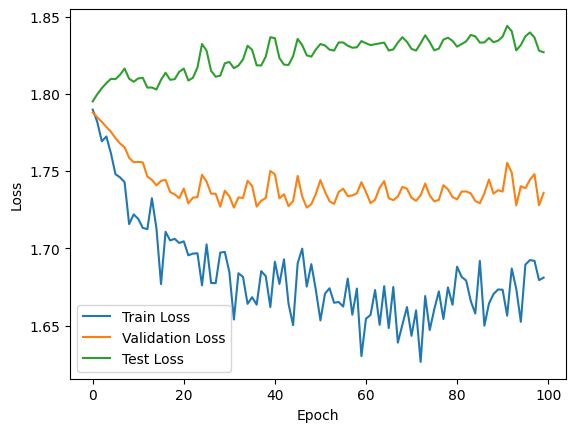

In [7]:
import matplotlib.pyplot as plt

plt.plot(all_train_loss, label='Train Loss')
plt.plot(all_val_loss, label='Validation Loss')
plt.plot(all_test_loss, label='Test Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.show()
